In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [57]:
# 1. Load the gene inventory you just parsed
df_genes = pd.read_csv('plasmid_gene_inventory.csv')

In [ ]:
# 2. Genes of interest identified during plasmid annotation analysis
# Maps each gene symbol to a descriptive label for visualization
genes_of_interest = {
    'merA': 'Mercury Reductase (merA)',
    'merP': 'Mercury Transport (merP)', 
    'emrE': 'QAC/Disinfectant Pump (emrE)',
    'proQ': 'Osmotic Regulator (proQ)',
    'relE': 'Toxin: RelE',
    'toxN': 'Toxin: ToxN',
    'bla': 'Beta-lactamase (bla)',
    'ant1': 'Streptomycin Res. (ant1)'
}

In [ ]:
# 3. Filter the gene inventory for known genes of interest using symbol or product keyword matching
target_genes = df_genes[df_genes['gene'].isin(genes_of_interest.keys()) | 
                        df_genes['product'].str.contains('mercury|osmotic|toxin', case=False)].copy()

# Maps raw gene symbols to their descriptive display labels
def clean_gene_name(row):
    for key, label in genes_of_interest.items():
        if isinstance(row['gene'], str) and key in row['gene']:
            return label
    return None

In [63]:
target_genes['clean_name'] = target_genes.apply(clean_gene_name, axis=1)
target_genes = target_genes.dropna(subset=['clean_name'])

# 4. Prepare the Matrix for Plotting
# Rows = Samples, Columns = Gene Names
gene_matrix = target_genes.pivot_table(index='Sample', columns='clean_name', aggfunc='size', fill_value=0)
gene_matrix = (gene_matrix > 0).astype(int)

In [ ]:
# 5. Plot Figure 11
plt.figure(figsize=(12, 7))

# Binary colormap: light gray for absent, deep purple-red for present
cmap_binary = mcolors.ListedColormap(['#f0f0f0', '#882255'])

sns.heatmap(gene_matrix, cmap=cmap_binary, linewidths=1, linecolor='white', cbar=False, annot=True, fmt="", square=True)

plt.title("Figure 11. Functional Gene Content of Unique LMF Plasmids", fontsize=14, pad=20)
plt.xlabel("Survival & Resistance Genes", fontsize=10, fontweight='bold')
plt.ylabel("LMF Isolates", fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Manual legend for presence/absence encoding
legend_elements = [
    Patch(facecolor='#882255', label='Gene Present'),
    Patch(facecolor='#f0f0f0', label='Gene Absent', edgecolor='gray')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Status")

plt.tight_layout()
# plt.savefig('Figure_11_Functional_Payload.png', dpi=300)
print("Figure 11 generated: Shows specific survival genes in LMF isolates.")

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_6720\4233308497.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


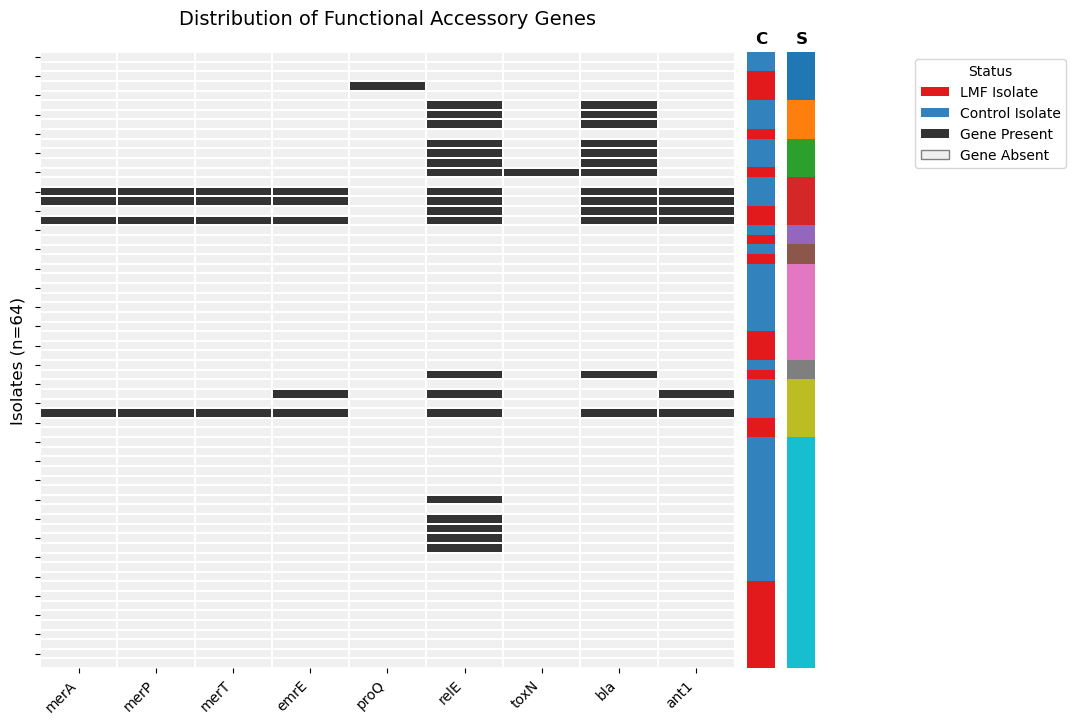

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# 1. Load Data
metadata = pd.read_csv('../../old/Final_65.csv')
gene_inventory = pd.read_csv('plasmid_gene_inventory.csv')

# 2. Preprocessing Metadata
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})

# 3. Define Genes of Interest (GOI)
# Based on the previous analysis of unique plasmids
goi_list = ['merA', 'merP', 'merT', 'emrE', 'proQ', 'relE', 'toxN', 'bla', 'ant1']
# Note: 'bla' might be generic, let's see. 

# 4. Create Presence/Absence Matrix
# We need to know if a genome has the gene in ANY of its plasmids
# First, filter inventory for GOIs. 
# We'll search in 'gene' column primarily, and maybe 'product' if gene is NaN but unlikely for these key ones.
# Let's clean the gene column in inventory
gene_inventory['gene_clean'] = gene_inventory['gene'].fillna('')

# Create a matrix: Index=Sample, Columns=GOI
# Initialize with 0 for all retained assemblies
gene_matrix = pd.DataFrame(0, index=metadata['Assembly'], columns=goi_list)

for gene in goi_list:
    # Find samples that have this gene
    # We use string contains to capture variants like bla_1, blaTEM, etc if necessary, 
    # but exact match is safer for gene symbols like 'merA'. 
    # Prokka usually outputs clean gene names. 
    # Let's try exact match first, or specific contains for things like 'bla'
    
    if gene == 'bla':
        has_gene = gene_inventory[gene_inventory['gene_clean'].str.contains('bla', case=False, na=False)]['Sample'].unique()
    elif gene == 'ant1': # ant(3'')-Ia often annotated as ant1 or similar
        has_gene = gene_inventory[gene_inventory['gene_clean'].str.contains('ant', case=False, na=False)]['Sample'].unique()
    else:
        has_gene = gene_inventory[gene_inventory['gene_clean'] == gene]['Sample'].unique()
        
    gene_matrix.loc[gene_matrix.index.isin(has_gene), gene] = 1

# 5. Sort Metadata for Heatmap (Lineage-based)
df_sorted = metadata.sort_values(['SNP cluster', 'Cohort']).reset_index(drop=True)
gene_matrix_sorted = gene_matrix.reindex(df_sorted['Assembly']).fillna(0).astype(int)

# 6. Plotting (Style of Figure 9/10)
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'}
PRESENCE_COLOR = '#333333'
ABSENCE_COLOR = '#f0f0f0'

unique_clusters = df_sorted['SNP cluster'].unique()
cluster_colors_list = sns.color_palette("tab10", len(unique_clusters))
cluster_palette = dict(zip(unique_clusters, cluster_colors_list))

fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(10, 8), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.05})

cmap_binary = mcolors.ListedColormap([ABSENCE_COLOR, PRESENCE_COLOR])
sns.heatmap(gene_matrix_sorted, ax=ax_main, cmap=cmap_binary, cbar=False, linewidths=0.1, linecolor='white')

ax_main.set_yticklabels([])
ax_main.set_title("Distribution of Functional Accessory Genes", fontsize=14, pad=20)
ax_main.set_xticklabels(goi_list, rotation=45, ha='right', fontsize=10)
ax_main.set_ylabel(f"Isolates (n={len(df_sorted)})", fontsize=12)

# Annotation Bars
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C", fontsize=12, fontweight='bold')

cluster_rgb = [mcolors.to_rgb(cluster_palette[s]) for s in df_sorted['SNP cluster']]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S", fontsize=12, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor=COHORT_PALETTE['LMF'], label='LMF Isolate'),
    Patch(facecolor=COHORT_PALETTE['Control'], label='Control Isolate'),
    Patch(facecolor=PRESENCE_COLOR, label='Gene Present'),
    Patch(facecolor=ABSENCE_COLOR, label='Gene Absent', edgecolor='gray')
]
ax_main.legend(handles=legend_elements, bbox_to_anchor=(1.25, 1), loc='upper left', title="Status")

plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('Figure_11_Gene_Heatmap.png', dpi=300)

Combined figure generated.


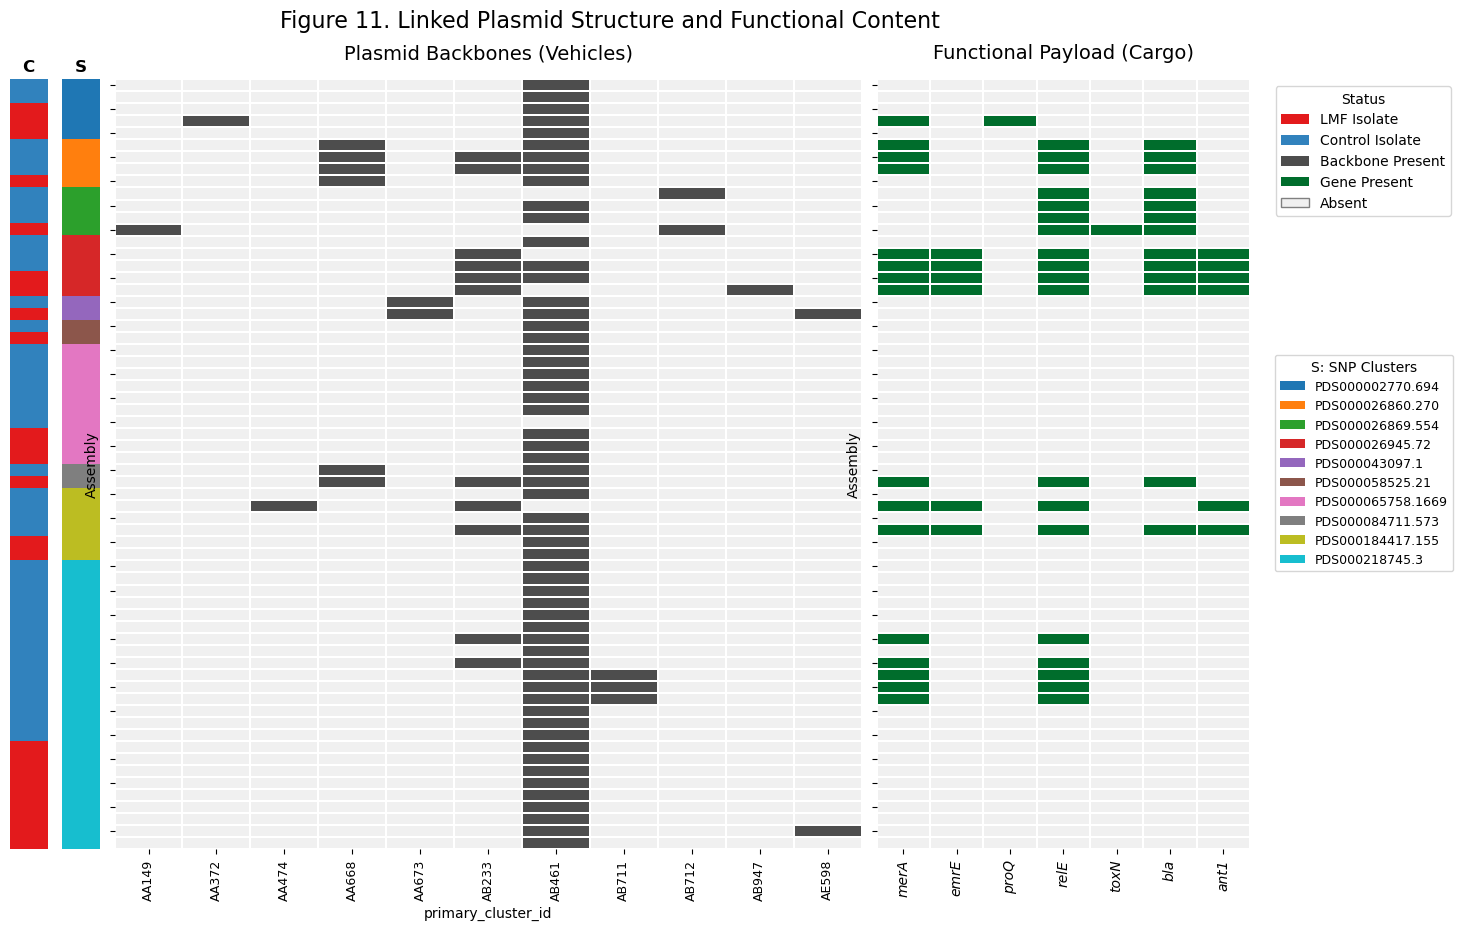

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# 1. Load Data
metadata = pd.read_csv('../../old/Final_65.csv')
mob_results = pd.read_csv('master_mobtyper_results.csv')
gene_inventory = pd.read_csv('plasmid_gene_inventory.csv')

# 2. Preprocessing
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})

# 3. Sort Metadata (The Backbone of the Figure)
df_sorted = metadata.sort_values(['SNP cluster', 'Cohort']).reset_index(drop=True)

# 4. Prepare LEFT Panel Data: Plasmid Backbones (Cluster IDs)
# Pivot the table
backbone_matrix = mob_results.pivot_table(index='Sample', columns='primary_cluster_id', aggfunc='size', fill_value=0)
backbone_matrix = (backbone_matrix > 0).astype(int)
# Reindex to match the sorted genomes
backbone_data = backbone_matrix.reindex(df_sorted['Assembly']).fillna(0).astype(int)

# 5. Prepare RIGHT Panel Data: Functional Genes
goi_list = ['merA', 'emrE', 'proQ', 'relE', 'toxN', 'bla', 'ant1']
gene_matrix = pd.DataFrame(0, index=metadata['Assembly'], columns=goi_list)

for gene in goi_list:
    # Robust search in 'gene' and 'product' columns
    hits = gene_inventory[
        gene_inventory['gene'].str.contains(gene, na=False, case=False) | 
        gene_inventory['product'].str.contains(gene, na=False, case=False)
    ]
    for sample in hits['Sample'].unique():
        if sample in gene_matrix.index:
            gene_matrix.loc[sample, gene] = 1

gene_data = gene_matrix.reindex(df_sorted['Assembly']).fillna(0).astype(int)

# 6. Colors and Aesthetics
COHORT_PALETTE = {'LMF': '#e31a1c', 'Control': '#3182bd'}
# Color for Backbones (Dark Gray)
BACKBONE_COLOR = '#4d4d4d' 
# Color for Genes (Teal/Green to distinguish from backbones?) Or keep same?
# Let's use a distinct color for Genes to make it clear it's different data
GENE_COLOR = '#006d2c' # Dark Green
ABSENCE_COLOR = '#f0f0f0'

unique_clusters = df_sorted['SNP cluster'].unique()
cluster_colors_list = sns.color_palette("tab10", len(unique_clusters))
cluster_palette = dict(zip(unique_clusters, cluster_colors_list))

# 7. Generate Combined Plot
# Layout: [Annotations][Backbones (Wide)][Genes (Narrower)]
fig, (ax_cohort, ax_cluster, ax_backbone, ax_gene) = plt.subplots(1, 4, figsize=(16, 10), 
                                                                 gridspec_kw={'width_ratios': [0.3, 0.3, 6, 3], 'wspace': 0.05})

# -- Annotations --
cohort_rgb = [mcolors.to_rgb(COHORT_PALETTE[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C", fontsize=12, fontweight='bold')

cluster_rgb = [mcolors.to_rgb(cluster_palette[s]) for s in df_sorted['SNP cluster']]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S", fontsize=12, fontweight='bold')

# -- Left Panel: Backbones --
cmap_backbone = mcolors.ListedColormap([ABSENCE_COLOR, BACKBONE_COLOR])
sns.heatmap(backbone_data, ax=ax_backbone, cmap=cmap_backbone, cbar=False, linewidths=0.1, linecolor='white')
ax_backbone.set_yticklabels([])
ax_backbone.set_title("Plasmid Backbones (Vehicles)", fontsize=14, pad=15)
ax_backbone.set_xticklabels(backbone_data.columns, rotation=90, fontsize=9)
# Add a vertical line to separate panels visually?
# ax_backbone.axvline(x=backbone_data.shape[1], color='black', linewidth=2)

# -- Right Panel: Genes --
cmap_gene = mcolors.ListedColormap([ABSENCE_COLOR, GENE_COLOR])
sns.heatmap(gene_data, ax=ax_gene, cmap=cmap_gene, cbar=False, linewidths=0.1, linecolor='white')
ax_gene.set_yticklabels([])
ax_gene.set_title("Functional Payload (Cargo)", fontsize=14, pad=15)
ax_gene.set_xticklabels(gene_data.columns, rotation=90, fontsize=10, fontstyle='italic')

# -- Legends --
# We need a combined legend
legend_elements = [
    Patch(facecolor=COHORT_PALETTE['LMF'], label='LMF Isolate'),
    Patch(facecolor=COHORT_PALETTE['Control'], label='Control Isolate'),
    Patch(facecolor=BACKBONE_COLOR, label='Backbone Present'),
    Patch(facecolor=GENE_COLOR, label='Gene Present'),
    Patch(facecolor=ABSENCE_COLOR, label='Absent', edgecolor='gray')
]

# SNP Cluster Legend (Reuse)
legend_snps = [Patch(facecolor=cluster_palette[clus], label=clus) for clus in unique_clusters]

# Add legends to the Gene panel (far right)
leg1 = ax_gene.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Status", fontsize=10)
ax_gene.add_artist(leg1)
ax_gene.legend(handles=legend_snps, bbox_to_anchor=(1.05, 0.65), loc='upper left', title="S: SNP Clusters", fontsize=9)

plt.suptitle("Figure 11. Linked Plasmid Structure and Functional Content", fontsize=16, y=0.95)
plt.savefig('Figure_11_Combined_Structure_Function.tiff', dpi=600, bbox_inches='tight')

print("Combined figure generated.")

In [103]:
import pandas as pd

# Load data
genes = pd.read_csv('plasmid_gene_inventory.csv')
metadata = pd.read_csv('../../old/Final_65.csv')

# Preprocess metadata
metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
metadata['Cohort'] = metadata['is_LMF'].map({1: 'LMF', 0: 'Control'})


In [105]:
# 1. Identify High Tier Clusters (>= 2 LMF isolates)
cluster_counts = metadata.groupby('SNP cluster')['is_LMF'].sum()
high_tier_clusters = cluster_counts[cluster_counts >= 2].index.tolist()

In [107]:
# 1. Identify High Tier Clusters (>= 2 LMF isolates)
cluster_counts = metadata.groupby('SNP cluster')['is_LMF'].sum()
high_tier_clusters = cluster_counts[cluster_counts >= 2].index.tolist()

In [117]:
high_tier_clusters

['PDS000002770.694',
 'PDS000026945.72',
 'PDS000065758.1669',
 'PDS000184417.155',
 'PDS000218745.3']

In [109]:
print(f"High Tier Clusters (>= 2 LMF): {high_tier_clusters}")

High Tier Clusters (>= 2 LMF): ['PDS000002770.694', 'PDS000026945.72', 'PDS000065758.1669', 'PDS000184417.155', 'PDS000218745.3']


In [115]:
# Analysis Loop
results = []

for cluster in high_tier_clusters:
    # Get assemblies
    cluster_meta = metadata[metadata['SNP cluster'] == cluster]
    lmf_assemblies = cluster_meta[cluster_meta['Cohort'] == 'LMF']['Assembly'].tolist()
    control_assemblies = cluster_meta[cluster_meta['Cohort'] == 'Control']['Assembly'].tolist()
    
    # Get genes for these assemblies
    # Filter genes df
    cluster_genes = genes[genes['Sample'].isin(lmf_assemblies + control_assemblies)]
    
    # We are interested in "plasmid_gene_inventory" products
    # Let's clean up product names (remove NaNs)
    cluster_genes = cluster_genes.dropna(subset=['product'])
    
    # Create sets of products for LMF and Control
    lmf_products = set(cluster_genes[cluster_genes['Sample'].isin(lmf_assemblies)]['product'])
    control_products = set(cluster_genes[cluster_genes['Sample'].isin(control_assemblies)]['product'])
    
    # Find Unique to LMF
    unique_lmf = lmf_products - control_products
    
    # Also find Shared but maybe interesting? 
    # For now, let's stick to unique or enriched.
    # To do enriched, we need counts.
    
    # Let's count prevalence
    # For each product in unique_lmf, how many LMF isolates have it?
    unique_lmf_details = []
    for prod in unique_lmf:
        # Count how many LMF samples have this product
        prod_genes = cluster_genes[cluster_genes['product'] == prod]
        count = prod_genes[prod_genes['Sample'].isin(lmf_assemblies)]['Sample'].nunique()
        unique_lmf_details.append({'product': prod, 'count': count, 'total_lmf': len(lmf_assemblies)})
    
    # Sort by count
    unique_lmf_details.sort(key=lambda x: x['count'], reverse=True)
    
    results.append({
        'cluster': cluster,
        'n_lmf': len(lmf_assemblies),
        'n_control': len(control_assemblies),
        'unique_lmf_products': unique_lmf_details
    })

# Print Results
for res in results:
    print(f"\n--- Cluster: {res['cluster']} (LMF: {res['n_lmf']}, Control: {res['n_control']}) ---")
    if not res['unique_lmf_products']:
        print("No unique LMF plasmid gene products found.")
    else:
        print(f"Found {len(res['unique_lmf_products'])} unique gene products in LMF group.")
        print("Top 10 Unique Products (by prevalence in LMF):")
        for item in res['unique_lmf_products'][:20]: # Show top 20
            print(f"  - {item['product']} ({item['count']}/{item['total_lmf']} isolates)")


--- Cluster: PDS000002770.694 (LMF: 3, Control: 2) ---
Found 17 unique gene products in LMF group.
Top 10 Unique Products (by prevalence in LMF):
  - IS200/IS605 family transposase IS609 (1/3 isolates)
  - Modulating protein YmoA (1/3 isolates)
  - Type IV secretion system protein VirB11 (1/3 isolates)
  - Type 3 secretion system secretin (1/3 isolates)
  - Replication initiation protein (1/3 isolates)
  - Type IV secretion system protein virB4 (1/3 isolates)
  - Protein TraL (1/3 isolates)
  - Protein QmcA (1/3 isolates)
  - Double-strand break reduction protein (1/3 isolates)
  - Inner membrane protein YbbJ (1/3 isolates)
  - Protein FlmC (1/3 isolates)
  - Type IV secretion system protein virB8 (1/3 isolates)
  - Endonuclease YhcR (1/3 isolates)
  - RNA chaperone ProQ (1/3 isolates)
  - Type IV secretion system protein virB1 (1/3 isolates)
  - Conjugal transfer protein TraG (1/3 isolates)
  - DNA topoisomerase 3 (1/3 isolates)

--- Cluster: PDS000026945.72 (LMF: 2, Control: 3) ---


In [119]:
# Target Cluster
target_cluster = 'PDS000218745.3'

In [121]:
# Get Assemblies
cluster_meta = metadata[metadata['SNP cluster'] == target_cluster]
lmf_assemblies = cluster_meta[cluster_meta['Cohort'] == 'LMF']['Assembly'].tolist()
control_assemblies = cluster_meta[cluster_meta['Cohort'] == 'Control']['Assembly'].tolist()

print(f"Analyzing Cluster: {target_cluster}")
print(f"LMF Isolates (n={len(lmf_assemblies)})")
print(f"Control Isolates (n={len(control_assemblies)})")

# Filter Genes
cluster_genes = genes[genes['Sample'].isin(lmf_assemblies + control_assemblies)].copy()
# Add Cohort info
cluster_genes['Cohort'] = cluster_genes['Sample'].map(cluster_meta.set_index('Assembly')['Cohort'])

# Count Prevalence per Gene Product
# Group by Product and Cohort, count unique Samples
gene_stats = cluster_genes.groupby(['product', 'Cohort'])['Sample'].nunique().unstack(fill_value=0)

# Add Totals and Percentages
gene_stats['LMF_Count'] = gene_stats.get('LMF', 0)
gene_stats['Control_Count'] = gene_stats.get('Control', 0)
gene_stats['LMF_Pct'] = (gene_stats['LMF_Count'] / len(lmf_assemblies)) * 100
gene_stats['Control_Pct'] = (gene_stats['Control_Count'] / len(control_assemblies)) * 100

# Filter: Look for genes with HIGH LMF prevalence and LOW Control prevalence
# Threshold: Present in at least 50% of LMF, but less than 20% of Control (or just 0)
potential_targets = gene_stats[
    (gene_stats['LMF_Pct'] > 40) & 
    (gene_stats['Control_Pct'] < 10)
].sort_values('LMF_Pct', ascending=False)

print("\n--- Potential LMF-Specific Markers in PDS000218745.3 ---")
if potential_targets.empty:
    print("No genes found that are present in >40% of LMF and <10% of Control.")
    # Fallback: Look for anything present in >1 LMF and 0 Control
    fallback = gene_stats[
        (gene_stats['LMF_Count'] >= 2) & 
        (gene_stats['Control_Count'] == 0)
    ].sort_values('LMF_Count', ascending=False)
    
    if fallback.empty:
        print("No genes found in >=2 LMF and 0 Control.")
        print("This implies the plasmid content is identical or variation is singleton-only.")
    else:
        print("Found rare variants (>=2 LMF, 0 Control):")
        print(fallback[['LMF_Count', 'Control_Count']])
else:
    print(potential_targets[['LMF_Count', 'Control_Count', 'LMF_Pct', 'Control_Pct']])

# Check the Core Plasmid similarity
# Are the "Core" genes (100% LMF) also 100% Control?
core_lmf = gene_stats[gene_stats['LMF_Pct'] == 100].index
core_control = gene_stats[gene_stats['Control_Pct'] == 100].index

print(f"\nCore Genes (100% prevalence):")
print(f"LMF Core Gene Count: {len(core_lmf)}")
print(f"Control Core Gene Count: {len(core_control)}")
print(f"Genes in LMF Core but NOT Control Core: {set(core_lmf) - set(core_control)}")

Analyzing Cluster: PDS000218745.3
LMF Isolates (n=9)
Control Isolates (n=15)

--- Potential LMF-Specific Markers in PDS000218745.3 ---
No genes found that are present in >40% of LMF and <10% of Control.
No genes found in >=2 LMF and 0 Control.
This implies the plasmid content is identical or variation is singleton-only.

Core Genes (100% prevalence):
LMF Core Gene Count: 24
Control Core Gene Count: 29
Genes in LMF Core but NOT Control Core: set()
